<a target="_blank" href="https://colab.research.google.com/github/binsue0/.github/blob/main/ML_day1/1_1_model_selection.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

#  Model Selection

Hands-on Machine Learning Chapter 2 (End-to-end Machine Learning Project) 참고

캘리포니아 주택가격 데이터로 **"어떤 모델을, 어떤 설정으로 쓸지 어떻게 고르는가"** 를 봅니다.

- 훈련 점수를 믿으면 안 되는 이유
- K-겹 교차 검증으로 모델 비교하기
- GridSearchCV / RandomizedSearchCV로 하이퍼파라미터 찾기
- 테스트 세트는 마지막에 딱 한 번

## 1. 데이터 준비

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/binsue0/.github/main/ML_day1/data/housing.csv'
housing = pd.read_csv(url)

housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
# 결측치와 범주형 변수를 확인합니다.
print(housing.shape)
print()
print('결측치:', housing.isna().sum().sum(), '개 (total_bedrooms)')
print()
print(housing['ocean_proximity'].value_counts())

(20640, 10)

결측치: 207 개 (total_bedrooms)

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


### 먼저 나누고, 그다음에 전처리

전처리(중앙값 대치, 표준화)의 기준값은 **훈련 세트에서만** 계산해야 합니다.
전체 데이터로 먼저 스케일링하면 테스트 정보가 훈련에 새어 들어갑니다(**데이터 누수**).

In [3]:
from sklearn.model_selection import train_test_split

X = housing.drop(columns='median_house_value')
y = housing['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((16512, 9), (4128, 9))

In [4]:
# 숫자형: 결측치 대치 -> 표준화 / 범주형: 원-핫 인코딩
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_attribs = [c for c in X.columns if c != 'ocean_proximity']
cat_attribs = ['ocean_proximity']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

prep = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', OneHotEncoder(), cat_attribs),
])

prep.fit_transform(X_train).shape       # 원-핫 인코딩으로 열이 늘어납니다

(16512, 13)

전처리를 파이프라인으로 묶어두면 **교차 검증을 할 때마다 폴드 안에서 다시 계산**되기 때문에
누수 없이 안전합니다. 모델까지 붙여서 하나로 만듭니다.

In [5]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = Pipeline([
    ('prep', prep),
    ('model', DecisionTreeRegressor(random_state=42)),
])

## 2. 훈련 점수는 믿을 수 없다

In [6]:
from sklearn.metrics import mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

tree_reg.fit(X_train, y_train)

print('train RMSE:', rmse(y_train, tree_reg.predict(X_train)).round(1))
print('test  RMSE:', rmse(y_test, tree_reg.predict(X_test)).round(1))

train RMSE: 0.0
test  RMSE: 69175.8


훈련 오차가 **0**입니다. 완벽한 모델일까요? 아니죠. 데이터를 통째로 외운 **과적합**입니다.
테스트에서는 약 7만 달러씩 틀립니다.

그렇다고 모델을 고를 때마다 테스트 세트를 보면 안 됩니다.
테스트 세트를 여러 번 쓰면 그 세트에 맞춰 고르게 되어 결국 **테스트 점수도 못 믿게** 됩니다.

그래서 **훈련 세트 안에서** 다시 나눠 평가합니다.

## 3. K-겹 교차 검증(K-fold cross validation)

훈련 세트를 K조각으로 나눠, 한 조각을 평가용으로 빼고 나머지로 학습하기를 K번 반복합니다.
점수가 K개 나오므로 **평균뿐 아니라 편차(안정성)** 까지 볼 수 있습니다.

In [7]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree_reg, X_train, y_train,
                         scoring='neg_root_mean_squared_error', cv=5)

# sklearn은 '클수록 좋은' 점수를 쓰므로 음수로 반환됩니다.
tree_rmse = -scores
tree_rmse.round(1)

array([71661.3, 69163.2, 69553.2, 67770.4, 70809.2])

In [8]:
print('평균  :', tree_rmse.mean().round(1))
print('표준편차:', tree_rmse.std().round(1))

평균  : 69791.5
표준편차: 1346.7


훈련 오차 0이었던 모델의 **진짜 실력은 약 7만**입니다. 이제 다른 모델과 비교해 봅시다.

In [9]:
from sklearn.linear_model import LinearRegression

lin_reg = Pipeline([('prep', prep), ('model', LinearRegression())])
lin_rmse = -cross_val_score(lin_reg, X_train, y_train,
                            scoring='neg_root_mean_squared_error', cv=5)

pd.DataFrame({
    'DecisionTree': [tree_rmse.mean(), tree_rmse.std()],
    'LinearRegression': [lin_rmse.mean(), lin_rmse.std()],
}, index=['RMSE 평균', 'RMSE 표준편차']).round(1)

,DecisionTree,LinearRegression
RMSE 평균,69791.5,68622.5
RMSE 표준편차,1346.7,1438.8


기본 설정만 놓고 보면 단순한 선형회귀가 오히려 낫습니다.
하지만 결정 트리는 **설정을 바꾸면 달라질 여지**가 큽니다. 이제 그 설정을 찾아봅시다.

## 4. GridSearchCV: 격자를 다 훑기

In [10]:
from sklearn.model_selection import GridSearchCV

# 파이프라인 안의 모델 파라미터는 'model__파라미터' 형식으로 씁니다.
param_grid = {
    'model__max_depth': [5, 10, 20, None],
    'model__max_features': [4, 8, 12],
}

grid_search = GridSearchCV(tree_reg, param_grid, cv=5,
                           scoring='neg_root_mean_squared_error')
grid_search.fit(X_train, y_train)

grid_search.best_params_

{'model__max_depth': 10, 'model__max_features': 12}

In [11]:
print('최고 교차검증 RMSE:', (-grid_search.best_score_).round(1))

최고 교차검증 RMSE: 63860.1


In [12]:
# 모든 조합의 결과를 볼 수 있습니다.
res = pd.DataFrame(grid_search.cv_results_)
res['RMSE'] = -res['mean_test_score']

res[['param_model__max_depth', 'param_model__max_features', 'RMSE']] \
    .sort_values('RMSE').head(6)

,param_model__max_depth,param_model__max_features,RMSE
5,10,12,63860.138502
4,10,8,64248.740497
3,10,4,67503.038919
8,20,12,69954.855427
2,5,12,70572.430652
7,20,8,70885.923772


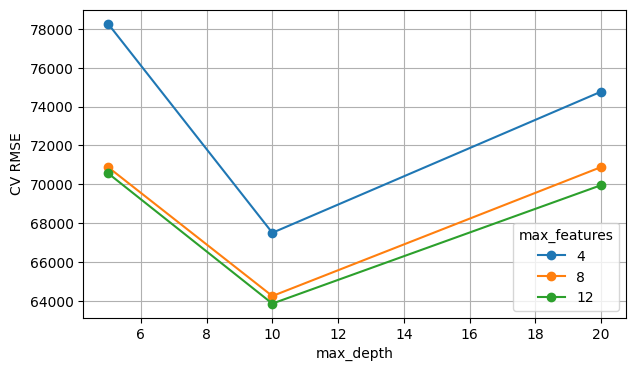

In [13]:
# 깊이에 따른 성능 변화를 그려봅니다.
pivot = res.pivot_table(index='param_model__max_depth',
                        columns='param_model__max_features',
                        values='RMSE', dropna=False)

pivot.plot(marker='o', figsize=(7, 4))
plt.xlabel('max_depth')
plt.ylabel('CV RMSE')
plt.legend(title='max_features')
plt.grid(True)
plt.show()

너무 얕으면 과소적합, 너무 깊으면 과적합이라 **중간에 최적점**이 있습니다.

## 5. RandomizedSearchCV: 무작위로 훑기

격자 탐색은 조합 수가 곱셈으로 늘어납니다. 파라미터 5개에 후보 5개씩이면 3,125번을 학습해야 하죠.
이럴 때는 **정해진 횟수만큼 무작위로 뽑아** 보는 쪽이 효율적입니다.

In [14]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'model__max_depth': randint(3, 30),
    'model__max_features': randint(2, 13),
    'model__min_samples_leaf': randint(1, 20),
}

rnd_search = RandomizedSearchCV(tree_reg, param_dist, n_iter=20, cv=5,
                                scoring='neg_root_mean_squared_error',
                                random_state=42)
rnd_search.fit(X_train, y_train)

print(rnd_search.best_params_)
print('최고 교차검증 RMSE:', (-rnd_search.best_score_).round(1))

{'model__max_depth': 23, 'model__max_features': 10, 'model__min_samples_leaf': 7}
최고 교차검증 RMSE: 59598.6


20번만 뽑아보고도 격자 탐색과 비슷하거나 더 좋은 조합을 찾았습니다.
(탐색 공간이 넓을수록 이 차이가 커집니다.)

## 6. 마지막에 딱 한 번: 테스트 세트

In [15]:
final_model = rnd_search.best_estimator_

final_rmse = rmse(y_test, final_model.predict(X_test))

print('처음 기본 트리 test RMSE :', rmse(y_test, tree_reg.predict(X_test)).round(1))
print('튜닝 후    test RMSE     :', final_rmse.round(1))

처음 기본 트리 test RMSE : 69175.8
튜닝 후    test RMSE     : 59495.9


같은 모델인데 설정만 바꿔서 오차가 눈에 띄게 줄었습니다.

이 점수는 **보고용**이지, 이걸 보고 다시 모델을 고치면 안 됩니다.
고치는 순간 테스트 세트도 훈련에 쓰인 셈이 되니까요.

In [16]:
# 어떤 특성이 중요했는지도 볼 수 있습니다.
importances = final_model.named_steps['model'].feature_importances_
names = final_model.named_steps['prep'].get_feature_names_out()

pd.Series(importances, index=names).sort_values(ascending=False).head(8)

,0
num__median_income,0.517832
cat__ocean_proximity_INLAND,0.160984
num__longitude,0.109328
num__latitude,0.106992
num__housing_median_age,0.039925
num__population,0.019643
num__total_bedrooms,0.016563
num__total_rooms,0.012278


## 정리

| 세트 | 쓰임 | 몇 번 쓰나 |
|---|---|---|
| 훈련(train) | 모델 학습 | 계속 |
| 검증(validation, 교차검증 폴드) | 모델·하이퍼파라미터 **선택** | 계속 |
| 테스트(test) | 최종 성능 **보고** | 딱 한 번 |

기억할 것
1. 훈련 오차가 0이면 좋은 게 아니라 **과적합 신호**다
2. 모델 비교는 **교차 검증 평균 ± 편차**로 한다
3. 전처리는 **파이프라인**에 넣어야 폴드마다 다시 계산되어 누수가 없다
4. 조합이 적으면 `GridSearchCV`, 넓으면 `RandomizedSearchCV`